# DFT in practical uses
In practical applications, the DFT result depends not only on the signal itself, but also on the selected data record, the window function, and how the spectrum is interpreted.

### Learning outcomes
By the end of this module, students shall be able to:
* Explain spectral leakage caused by finite-length data records and non-bin-centered frequencies.
* Compare window functions and select an appropriate window for a given spectral-analysis task.
* Explain the effect of zero padding on spectral display and frequency resolution.
* Estimate frequency and amplitude from a DFT while accounting for scalloping loss and coherent gain.

There are 4 sections in this lecture.
1. From ideal condition to real signal
2. Windowing and trade-off
3. Reading frequency and amplitude correctly
4. Practical consideration using the DFT

## 1. From ideal condition to real signal
In the previous lecture, students saw that the pure tone signal can be depicted by the corresponding frequency index in the frequency domain. 

**But, what if the signal frequency is not alighed with the frequency index?**

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from ipywidgets import interact, fixed

In [2]:
def plotSinusoid(f=8,A=1,fs=400,N=50,period=1):
    n = np.arange(N)
    Ts = 1/fs
    tn = n*Ts
    x = A*np.cos(2*np.pi*f*tn)
    X = np.fft.fft(x)
    X_oneside = X[0:N//2 +1]
    k = np.arange(len(X_oneside))
    df = fs/N
    fk = k*df
    fig, ax = plt.subplots(2,1,constrained_layout=True)
    x_plot = np.array([])
    for i in range(period):
        x_plot = np.concatenate((x_plot, x))
    t_plot = np.arange(N*period)*Ts
    ax[0].stem(t_plot,x_plot)
    ax[1].stem(fk,np.abs(X_oneside))

In [3]:
interact(plotSinusoid,f=(0,100),A=fixed(1),fs=fixed(400),N=fixed(50),period=fixed(1))

interactive(children=(IntSlider(value=8, description='f'), Output()), _dom_classes=('widget-interact',))

<function __main__.plotSinusoid(f=8, A=1, fs=400, N=50, period=1)>

### But Why?

* In the previous example, (N=50), so the data record contains samples (0) to (49).
* The DFT analyzes only these 50 samples.
* It has no information about the signal before or after this record.
* To understand how the DFT represents this finite record, we can reconstruct it using the IDFT.

 

### Inverse Discrete Fourier Transform
The DFT is defined by:
\\[
\mathbf{X}[k] = \sum_{n=0}^{N-1}x[n]e^{-j2\pi kn/N}
\\]
The IDFT is defined as 
\\[
x[n] = \frac{1}{N}\sum_{k=0}^{N-1}\mathbf{X}[k]e^{j2\pi kn/N}
\\]

#### Exercise (10 minutes, group of four)
1. Let $x[n] = \{0, 1, 2, 3 \}$, please determine $\mathbf{X}[k]$ for $0\leq k < 4$ (Students can simply use `np.fft.fft` for this task)
2. Use the determined $\mathbf{X}[k]$ to determine $x[n]$ for $4\leq n < 8$ (No function can do this, but students can use any programming language to do the calculation)

In [4]:
x = np.array([0,1,2,3])
X = np.fft.fft(x)
print(X)

[ 6.+0.j -2.+2.j -2.+0.j -2.-2.j]


In [5]:
def cal_xn(X,n):
    N = len(X)
    sumX = 0
    for k in range(len(X)):
        sumX = sumX + X[k]*np.exp(1j*2*np.pi*k*n/N)
    xn = sumX/N
    return np.round(np.real_if_close(xn),3)

In [6]:
x4 = cal_xn(X,5)
print(x4)

1.0


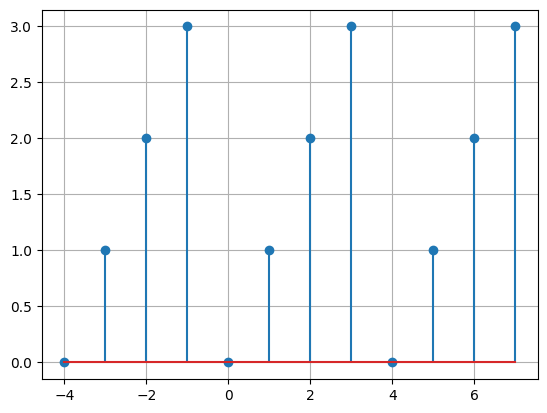

In [7]:
# If we plot x[n] ; -4 <= n < 8
n = np.arange(-4,8)
x = np.array([0,1,2,3,0,1,2,3,0,1,2,3])
plt.stem(n,x)
plt.grid()

### Periodic Extension

A real-world signal may not be periodic. However, the DFT treats an (N)-sample frame as one period of a repeating sequence.

**This repetition is implied by the DFT, not necessarily present in the original signal.** This pheomenon is called the periodic extension.

\\[
x[n+N] = x[n]
\\]

Even though you see this fact by yourselve already, it is nice to see how does this happen in mathematic.

### Periodicity of IDFT
Consider the IDFT
\\[
x[n] = \frac{1}{N}\sum_{k=0}^{k=N-1}\mathbf{X}[k]e^{2\pi kn/N}
\\]
If we want to calculate $x[n+N]$,
\\[
\begin{align}
x[n+N] &= \frac{1}{N}\sum_{k=0}^{k=N-1}\mathbf{X}[k]e^{2\pi k(n+N)/N} \\
       &= \frac{1}{N}\sum_{k=0}^{k=N-1}\mathbf{X}[k][e^{2\pi kn/N}][e^{2\pi kN/N}] \\
       &= \frac{1}{N}\sum_{k=0}^{k=N-1}\mathbf{X}[k]e^{2\pi kn/N} \\
x[n+N] &= x[n]
\end{align}
\\]

### Abrubt change at the junction between period
Because the periodic nature of the DFT calculation, if the end of one repeated frame does not connect smoothly to the beginning of the next, an abrupt change appears at the frame boundary.

For a sinusoid, this occurs when the frame contains a non-integer number of cycles. In another word, the frequency is not aligned with the frequency bin.

\\[
f_{k} = k\frac{fs}{N}
\\]

In [8]:
interact(plotSinusoid,f=(0,100),A=fixed(1),fs=fixed(400),N=fixed(50),period=fixed(2))

interactive(children=(IntSlider(value=8, description='f'), Output()), _dom_classes=('widget-interact',))

<function __main__.plotSinusoid(f=8, A=1, fs=400, N=50, period=1)>

### Frequency Leakage
This phenomenon is called the **Frequency leakage**.
* Happen when the frequency components of the signal are not aligned with the bin $f_{k} = k\frac{f_{s}}{N}$
* Unavoidable in analysis of the real signal
* Its effects could be reduced by applying a **time window** function to the frames of recorded data


## 2. Windowing
When an \(N\)-sample frame is periodically extended, a discontinuity may appear
between the end of one frame and the beginning of the next.

A **window function** assigns a weight to each sample in the frame:

\\[
x_w[n] = x[n]w[n]
\\]

Samples near the center may be kept nearly unchanged, while samples near the
two boundaries can be reduced.

When we select the $N$-sample frame without any weighting function, it is equivalent to applying a rectangular window, which is defined as:

\\[
w[n] =
\begin{cases}
1, & 0 \leq n < N \\
0, & \text{otherwise}
\end{cases}
\\]

This window does not help reducing discontinuity at the boundaries of the periodic extension at all.

**Can we reduce the boundary discontinuity by gradually reducing the samples
near the beginning and the end of the frame?**

In [19]:
def plotWindowed(window,f0=26,periodic=False):
    L = 100
    fs = 400
    Ts = 1/fs
    n = np.arange(L)
    tl = n*Ts
    sig = np.cos(2*np.pi*f0*tl)
    N = 50
    match window:
        case "Rectangular":
            win = np.ones(N)
        case "Bartlett":
            win = np.bartlett(N)
        case "Hamming":
            win = np.hamming(N)
        case "Hann":
            win = np.hanning(N)
    win_fill = np.concatenate((win,np.zeros(L-N)))
    if not periodic:
        sig_fill = sig*win_fill
    else:
        sig_fill = np.concatenate((sig[0:N]*win,sig[0:N]*win))
    fig, ax = plt.subplots(3,1,sharex=True,figsize = (9,6),constrained_layout=True)
    ax[0].stem(n,sig)
    ax[0].set_ylabel(r"$x[n]$")
    ax[0].set_title("Original signal")
    
    ax[1].stem(n,win_fill)
    ax[1].set_ylabel(r"$w[n]$")
    ax[1].set_title(f"{window} Window")
    
    ax[2].stem(n,sig_fill)
    ax[2].set_ylabel(r"$x[n]*w[n]$")
    ax[2].set_title("Windowed signal")
    ax[2].set_xlabel("Sample index $n$")

    for axi in ax:
        axi.axvline(N-1,linestyle='--')
        

In [20]:
interact(plotWindowed, window = ['Rectangular','Hann'], f0=(0,200), periodic=False)

interactive(children=(Dropdown(description='window', options=('Rectangular', 'Hann'), value='Rectangular'), In…

<function __main__.plotWindowed(window, f0=26, periodic=False)>

### Spectrum of the windowed signal

In [11]:
def plotWindowedSpectrum(window,f0 = 26,logscale=False):
    N = 50
    fs = 400
    Ts = 1/fs
    n = np.arange(N)
    tn = n*Ts
    sig = np.cos(2*np.pi*f0*tn)
    match window:
        case "Rectangular":
            win = np.ones(N)
        case "Bartlett":
            win = np.bartlett(N)
        case "Hamming":
            win = np.hamming(N)
        case "Hann":
            win = np.hanning(N)
        case "Blackman":
            win = np.blackman(N)
    
    sigwin = sig*win
    SigWin = np.fft.fft(sigwin)
    Sig = np.fft.fft(sig)
    
    fig, ax = plt.subplots(3,1,figsize = (6,8), constrained_layout=True)
    ax[0].stem(n,sig)
    ax[0].set_ylabel(r"Origial signal: $x[n]$")
    ax[0].sharex(ax[1])
    
    ax[1].stem(n,sigwin)
    ax[1].plot(n,win,"--",color="gray")
    ax[1].set_ylabel(f"{window} Windowed: $x[n]w[n]$")
    ax[1].set_xlabel("Time index - $n$")
    k = np.arange(len(Sig))
    if logscale:
        ax[2].plot(k[0:N//2 + 1],20*np.log10(np.abs(Sig[0:N//2 + 1])),"--ok")
        ax[2].plot(k[0:N//2 + 1],20*np.log10(np.abs(SigWin[0:N//2 + 1])), "-o")
        ax[2].set_ylabel(r"Spectrum (dB): $20\log(|\mathbf{X}[k]|)$")
    else:
        ax[2].plot(k[0:N//2 + 1],np.abs(Sig[0:N//2 + 1]), "--ok")
        ax[2].plot(k[0:N//2 + 1],np.abs(SigWin[0:N//2 + 1]), "-o")
        ax[2].set_ylabel(r"Spectrum (linear): $|\mathbf{X}[k]|$")
    ax[2].grid(True)
    ax[2].set_xlabel("Frequency index - $k$")   

In [12]:
interact(plotWindowedSpectrum, window=['Rectangular','Hamming','Hann','Blackman'],f0 = (0,50), logscale=False)

interactive(children=(Dropdown(description='window', options=('Rectangular', 'Hamming', 'Hann', 'Blackman'), v…

<function __main__.plotWindowedSpectrum(window, f0=26, logscale=False)>

### Trade-offs
Did you notice the differences?
* How does the peak change?
* How does the leakage change?

Compared with the rectangular window:

- The peak becomes lower.
- The peak spreads over a wider range of frequency bins.
- The small components far from the peak become lower.

#### Terminologies
* The large central part around the peak is called the **main lobe**.
* The smaller ripples away from the peak are called **side lobes**.

### Trade-offs with DSP terminologies
A tapered window usually gives:
- Lower peak amplitude → amplitude correction is needed
- Wider main lobe → nearby frequencies are harder to separate
- Lower side lobes → less leakage far from the peak

### Choosing a window
Since every window has trade-offs, the practical question is not “Which window is best?” but **“Which window is suitable for the task?”**

A window is not simply “better” or “worse”.

Different windows make different trade-offs:

- narrow peak region vs. low leakage
- good frequency separation vs. good leakage suppression
- simple amplitude reading vs. required amplitude correction

Therefore, the practical question is:

**What do we need from the spectrum?**

### Analysis goals
| Analysis goal                    | Prefer                                |
| -------------------------------- | ------------------------------------- |
| Separate nearby frequencies      | Narrower main lobe                    |
| Reduce leakage far from the peak | Lower side lobes                      |
| Estimate amplitude               | Use correction / know the window gain |
| General-purpose spectral display | Hann is often a reasonable start      |


### Windows' characters
In this lesson, we focus on a few representative windows:

| Window | Practical meaning |
|---|---|
| Rectangular | No taper; sharp peak but high leakage |
| Hann | General-purpose taper; lower leakage but wider peak |
| Hamming | Similar to Hann; different side-lobe behavior |
| Blackman | Stronger leakage reduction; even wider peak |

The goal is not to memorize many windows, but to understand the trade-off.

### Notes on Hamming window and Hann window
You see the table said, "Hamming: Similar to Hann, different side-lobe behavior". But what does it refer to?

#### Technical aspect
Both are in the same window family (rised cosine, we will talk about it later), but 
* Hann window brings the end points to zeros,
* which makes side-lobe role-off well, while
* Hamming window keeps the end points to small weights.
* which suppresses the first side-lobe more but worsen the rest side-lobe roll-off.


#### Historical aspect
Hann window named after [Julius von Hann](https://en.wikipedia.org/wiki/Julius_von_Hann), so the correct term is "Hann window" not "Hanning window".

Hamming window named after [Richard Wesley Hamming](https://en.wikipedia.org/wiki/Richard_Hamming), so the word "Hamming" is not present continuous of "Hamm".

### Choosing a Window by Analysis Concern

| Main concern                    | Example task                                             | Suitable window(s) | Reason                                                                                          |
| ------------------------------- | -------------------------------------------------------- | ------------------ | ----------------------------------------------------------------------------------------------- |
| Narrow spectral peaks           | Controlled tone, stable machine vibration                | Rectangular, Hann  | Rectangular gives the narrowest peak, but Hann is safer when bin alignment is uncertain.        |
| Leakage hides weak components   | Harmonic analysis, sidebands, weak tone near strong tone | Hamming, Blackman  | These windows reduce leakage from strong components, with Blackman giving stronger suppression. |
| General audio/acoustic spectrum | Music, speech, environmental sound                       | Hann               | A safe general-purpose choice for off-bin frequency components.                                 |
| Broadband/random-like signal    | White noise, pink noise, construction noise              | Hann + averaging   | Windowing helps, but averaging is more important for stable spectral estimates.                 |
| Truncated impulse response      | Room IR, early reflection analysis                       | Hann, Tukey        | Tapering the time gate reduces artifacts from abrupt truncation.                                |


### Key Takeaway

A window is not chosen by name.

It is chosen by deciding what error is most important:

- leakage from strong components
- peak widening
- amplitude attenuation
- artifacts from time truncation

There is no universally best window.

## 3. Corrections
We first consider the scaling of the DFT magnitude.

The following plot shows the DFT magnitude before applying any window correction.

In [13]:
def plotRawDFT(N,f0,normalized=False,oneside=False):
    fs = 400
    n = np.arange(N)
    tn = n*(1/fs)
    x = np.cos(2*np.pi*f0*tn)
    X = np.fft.fft(x)
    X_plot = np.abs(X)

    if oneside:
        k = np.arange(N//2+1)
        X_plot = X_plot[0:N//2+1]
        if N%2 == 1:
            X_plot[1:N//2+1] = 2*X_plot[1:N//2+1]
        else:
            X_plot[1:N//2] = 2*X_plot[1:N//2]
    else:
        k = np.arange(-N//2,N//2)
        X_plot = np.fft.fftshift(X_plot)
    
    if normalized:
        X_plot = X_plot/N
        
    fig, ax = plt.subplots(2,1,constrained_layout=True)
    ax[0].stem(n,x)
    ax[0].set_xlabel(r"Time index: $n$")
    ax[0].set_ylabel(r"$x[n]$")
    ax[1].stem(k,X_plot)
    ax[1].set_xlabel(r"Frequency index: $k$")
    ax[1].set_ylabel(r"$|\mathbf{X}[k]|$")

In [14]:
interact(plotRawDFT, N=(50,500,50), f0=(0,100,8),normalized=False)

interactive(children=(IntSlider(value=250, description='N', max=500, min=50, step=50), IntSlider(value=48, des…

<function __main__.plotRawDFT(N, f0, normalized=False, oneside=False)>

### From DFT Magnitude to Amplitude

In NumPy, the forward DFT is not normalized:

\\[
X[k]=\sum_{n=0}^{N-1}x[n]e^{-j2\pi kn/N}
\\]

For a real sinusoid at a DFT bin, the amplitude appears in two bins:
one at positive frequency and one at negative frequency.

Therefore, for a one-sided amplitude spectrum:

\\[
A[k] =
\begin{cases}
\dfrac{|X[k]|}{N}, & k=0 \\
\dfrac{2|X[k]|}{N}, & 1\le k < N/2 \\
\dfrac{|X[k]|}{N}, & k=N/2 \text{ if } N \text{ is even}
\end{cases}
\\]

The factor 2 is used only for bins that have a negative-frequency counterpart.
DC and Nyquist bins are not doubled.

### Different Corrections for Different Quantities

The correction depends on what we want to measure.

| Quantity of interest | Use |
|---|---|
| Amplitude of a sinusoidal peak | Coherent gain, \\(\sum w[n]\\) |
| Power / RMS / energy | Window power, \\(\sum w^2[n]\\) |
| PSD / band power | PSD scaling with \\(f_s\sum w^2[n]\\) |

#### **Remark**
In this section, we first correct the amplitude of a sinusoidal component.

### Window Attenuation for Amplitude

When a window is applied,

\\[
x_w[n] = x[n]w[n]
\\]

the peak amplitude of a bin-centered sinusoid is reduced.

For amplitude measurement, the relevant window factor is the average value of the window:

\\[
CG = \frac{1}{N}\sum_{n=0}^{N-1}w[n]
\\]

This is called the coherent gain.

The amplitude spectrum $A[k]$ is then expressed by:
\\[
A_{corrected}[k] = \frac{A[k]}{CG}
\\]

This corrects the amplitude of a sinusoidal peak.

### **Important Warning**
Amplitude correction and power correction are not the same.
**DO NOT** use coherent-gain corrected amplitude spectra to compute band power.

For power or PSD, use the window power normalization factor:

\\[
U = \frac{1}{N}\sum w^2[n]
\\]

We will talk about power spectrum later. Now let's focus on the magnitude spectrum only.

In [15]:
def plotWindowedSpectrum(window,f0 = 24,logscale=False, correction=False):
    N = 50
    fs = 400
    Ts = 1/fs
    n = np.arange(N)
    tn = n*Ts
    sig = np.cos(2*np.pi*f0*tn)
    match window:
        case "Rectangular":
            win = np.ones(N)
        case "Bartlett":
            win = np.bartlett(N)
        case "Hamming":
            win = np.hamming(N)
        case "Hann":
            win = np.hanning(N)
        case "Blackman":
            win = np.blackman(N)
    
    sigwin = sig*win
    SigWin = np.fft.fft(sigwin)/N
    SigWin_plot = SigWin[0:N//2+1]*2
    SigWin_plot[0] = SigWin_plot[0]/2
    
    Sig = np.fft.fft(sig)/N
    Sig_plot = Sig[0:N//2+1]*2
    Sig_plot[0] = Sig_plot[0]/2
    if N%2==0:
        Sig_plot[-1] = Sig_plot[-1]/2
        SigWin_plot[-1] = SigWin_plot[-1]/2

    if correction:
        CG = np.sum(win)/N
    else:
        CG = 1
    fig, ax = plt.subplots(3,1,figsize = (6,8), constrained_layout=True)
    ax[0].stem(n,sig)
    ax[0].set_ylabel(r"Origial signal: $x[n]$")
    ax[0].sharex(ax[1])
    
    ax[1].stem(n,sigwin)
    ax[1].plot(n,win,"--",color="gray")
    ax[1].set_ylabel(f"{window} Windowed: $x[n]w[n]$")
    ax[1].set_xlabel("Time index - $n$")
    k = np.arange(len(Sig))
    if logscale:
        ax[2].plot(k[0:N//2 + 1],20*np.log10(np.abs(Sig_plot)),"--ok")
        ax[2].plot(k[0:N//2 + 1],20*np.log10(np.abs(SigWin_plot/CG)), "-o")
        ax[2].set_ylabel(r"Spectrum (dB): $20\log(|\mathbf{X}[k]|)$")
    else:
        ax[2].plot(k[0:N//2 + 1],np.abs(Sig_plot), "--ok")
        ax[2].plot(k[0:N//2 + 1],np.abs(SigWin_plot/CG), "-o")
        ax[2].set_ylabel(r"Spectrum (linear): $|\mathbf{X}[k]|$")
    ax[2].grid(True)
    ax[2].set_xlabel("Frequency index - $k$")   

In [16]:
interact(plotWindowedSpectrum,window=['Rectangular','Hamming','Hann','Blackman'],f0=(0,50,4),logscale=False,correction=False)

interactive(children=(Dropdown(description='window', options=('Rectangular', 'Hamming', 'Hann', 'Blackman'), v…

<function __main__.plotWindowedSpectrum(window, f0=24, logscale=False, correction=False)>

### When the frequency is not at the bin
The frequency bins are located at:
\\[
f_{k} = k\cdot\frac{f_{s}}{N}
\\]

The coherent gain correction assumes that the sinusoid is aligned with a DFT bin.

If the frequency falls between bins, the largest bin may still be lower than the true amplitude.

### Zero padding
**Zero padding** pads zeros at the end of the signal. When the DFT takes the zero padded signal, the $N$-point for the DFT process increases. Consequenctly, **the frequency grid finer**, so the shape of the spectrum can be seen more clearly.

\\[
N\_FFT > N_SignalFrame
\\]

### **Warning!**
Zero padding interpolates the DFT display. It does not create new measured data. Two close tones that cannot be resolved from the original record will not become truly resolvable just by zero padding.

In [17]:
def plotWindowedSpectrum(window, f0=24, logscale=False, correction=False, zpfactor=2):
    N = 50
    fs = 400
    Ts = 1/fs
    Nfft = N * zpfactor
    
    n = np.arange(N)
    nl = np.arange(Nfft)
    tn = nl * Ts
    sig = np.cos(2*np.pi*f0*tn)

    match window:
        case "Rectangular":
            win = np.ones(N)
        case "Bartlett":
            win = np.bartlett(N)
        case "Hamming":
            win = np.hamming(N)
        case "Hann":
            win = np.hanning(N)
        case "Blackman":
            win = np.blackman(N)

    win = np.concatenate((win,np.zeros(Nfft-N)))
    sigwin = sig * win
    
    # one-sided FFT
    Sig = np.fft.rfft(sig, n=Nfft)
    SigWin = np.fft.rfft(sigwin, n=Nfft)

    k = np.arange(len(Sig))

    # one-sided factor
    scale = np.ones(len(Sig))
    scale[1:] = 2

    if Nfft % 2 == 0:
        scale[-1] = 1

    # Original signal amplitude spectrum
    Sig_amp = scale * np.abs(Sig) / Nfft

    # Windowed signal amplitude spectrum
    if correction:
        SigWin_amp = scale * np.abs(SigWin) / np.sum(win)
        corr_text = "with coherent-gain correction"
    else:
        SigWin_amp = scale * np.abs(SigWin) / N
        corr_text = "without coherent-gain correction"

    fig, ax = plt.subplots(3, 1, figsize=(6, 7), constrained_layout=True)

    ax[0].stem(nl, sig)
    ax[0].set_ylabel(r"Original signal: $x[n]$")
    ax[0].sharex(ax[1])

    ax[1].stem(nl,sigwin)
    ax[1].plot(nl, win, "--", color="gray")
    ax[1].set_ylabel(rf"{window}: $x[n]w[n]$")
    ax[1].set_xlabel(r"Time index: $n$")

    eps = 1e-12

    if logscale:
        ax[2].plot(k, 20*np.log10(Sig_amp + eps), "--ok", label="Original")
        ax[2].plot(k, 20*np.log10(SigWin_amp + eps), "-o", label=f"{window}, {corr_text}")
        ax[2].set_ylabel("Amplitude (dB re. 1)")
    else:
        ax[2].plot(k, Sig_amp, "--ok", label="Original")
        ax[2].plot(k, SigWin_amp, "-o", label=f"{window}, {corr_text}")
        ax[2].set_ylabel("Amplitude spectrum")

    ax[2].grid(True)
    ax[2].set_xlabel(r"Frequency index: $k$")
    ax[2].legend()

    CG = np.sum(win) / N
    ax[2].set_title(
        rf"$N={N}$, $N_{{FFT}}={Nfft}$, $f_0={f0}$ Hz, CG={CG:.3f}"
    )

In [18]:
interact(plotWindowedSpectrum,window=["Rectangular", "Hann", "Hamming", "Blackman"],
    f0=(8, 80, 1),logscale=False,correction=False,zpfactor=[1,2,4,8])

interactive(children=(Dropdown(description='window', options=('Rectangular', 'Hann', 'Hamming', 'Blackman'), v…

<function __main__.plotWindowedSpectrum(window, f0=24, logscale=False, correction=False, zpfactor=2)>

### Scallop loss
When a sinusoid falls between DFT bins, the largest sampled bin may be lower than the true peak. This amplitude error is called scalloping loss.

However, we do not fully correct scalloping loss here. We only show that it exists, and that zero padding can help us see the peak location more clearly.

### Summary of Corrections

For a practical magnitude spectrum, several adjustments may be needed:

| Issue | Correction / action |
|---|---|
| FFT magnitude depends on record length | Normalize by \(N\) |
| Real signals have positive and negative frequency components | Use one-sided scaling |
| Windowing reduces peak amplitude | Correct by coherent gain |
| Frequency grid may be too coarse | Use zero padding for display and peak inspection |
| Tone may fall between DFT bins | Be aware of scalloping loss |

These corrections do not remove the fundamental trade-offs of windowing.

### Key Takeaway

Amplitude correction can recover the scale of a sinusoidal peak.

Zero padding can make the spectrum easier to inspect.

However, neither correction removes leakage, main-lobe widening, or scalloping loss completely.

### From Concept to Workflow

In the lab session, we will use the practical DFT workflow:

1. Select a data record.
2. Choose a window.
3. Compute the FFT.
4. Apply the correct amplitude scaling.
5. Use zero padding for peak inspection.
6. Interpret the spectrum carefully.

The goal is not only to compute the DFT, but to understand what the spectrum is telling us.

# Q&A